#### E-Commerce Customer Segmentation/clustering System

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("D:\Courses\AI-ML PRIME\AIML - Projects\Minor-Projects\SmartCard Clustering System\smartcart_customers.csv")

data.head()
data.shape

(2240, 22)

In [7]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handling Missing Values

In [12]:
data["Income"] = data["Income"].fillna(data["Income"].median())

In [13]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [14]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [ ]:
# Adding he new feature ---> Age
max_year = data["Year_Birth"].max()

data["Age"] = max_year - data["Year_Birth"]


1893

In [21]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [26]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)

reference_date = data["Dt_Customer"].max()

data["Customer_Tenure_Days"]= (reference_date - data["Dt_Customer"]).dt.days

In [27]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [30]:
# Adding 2 More new features----> Totoal purchases and total children

data["Total_spending"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

data["Total_Children"] = data["Kidhome"] + data["Teenhome"]


In [31]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [33]:
## Education  ---- > Graduate, Undergraduate, Postgraduate

data["Education"].value_counts()

data["Education"] =data["Education"].replace({
    "Basic" :"Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})

In [34]:
data["Education"].value_counts()

Education
Graduation       1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [35]:
### Martial Status

data["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [36]:
## Lets create new feature Living_with

data["Living_with"] = data["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Single" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

data["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

### Dropping Columns

In [38]:
columns = ["ID", "Year_Birth", "Marital_Status", "Dt_Customer","Kidhome","Teenhome"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = columns + spending_cols

data_cleaned = data.drop(columns=cols_to_drop)

In [39]:
data_cleaned.shape

(2240, 15)

## Handling Outliers

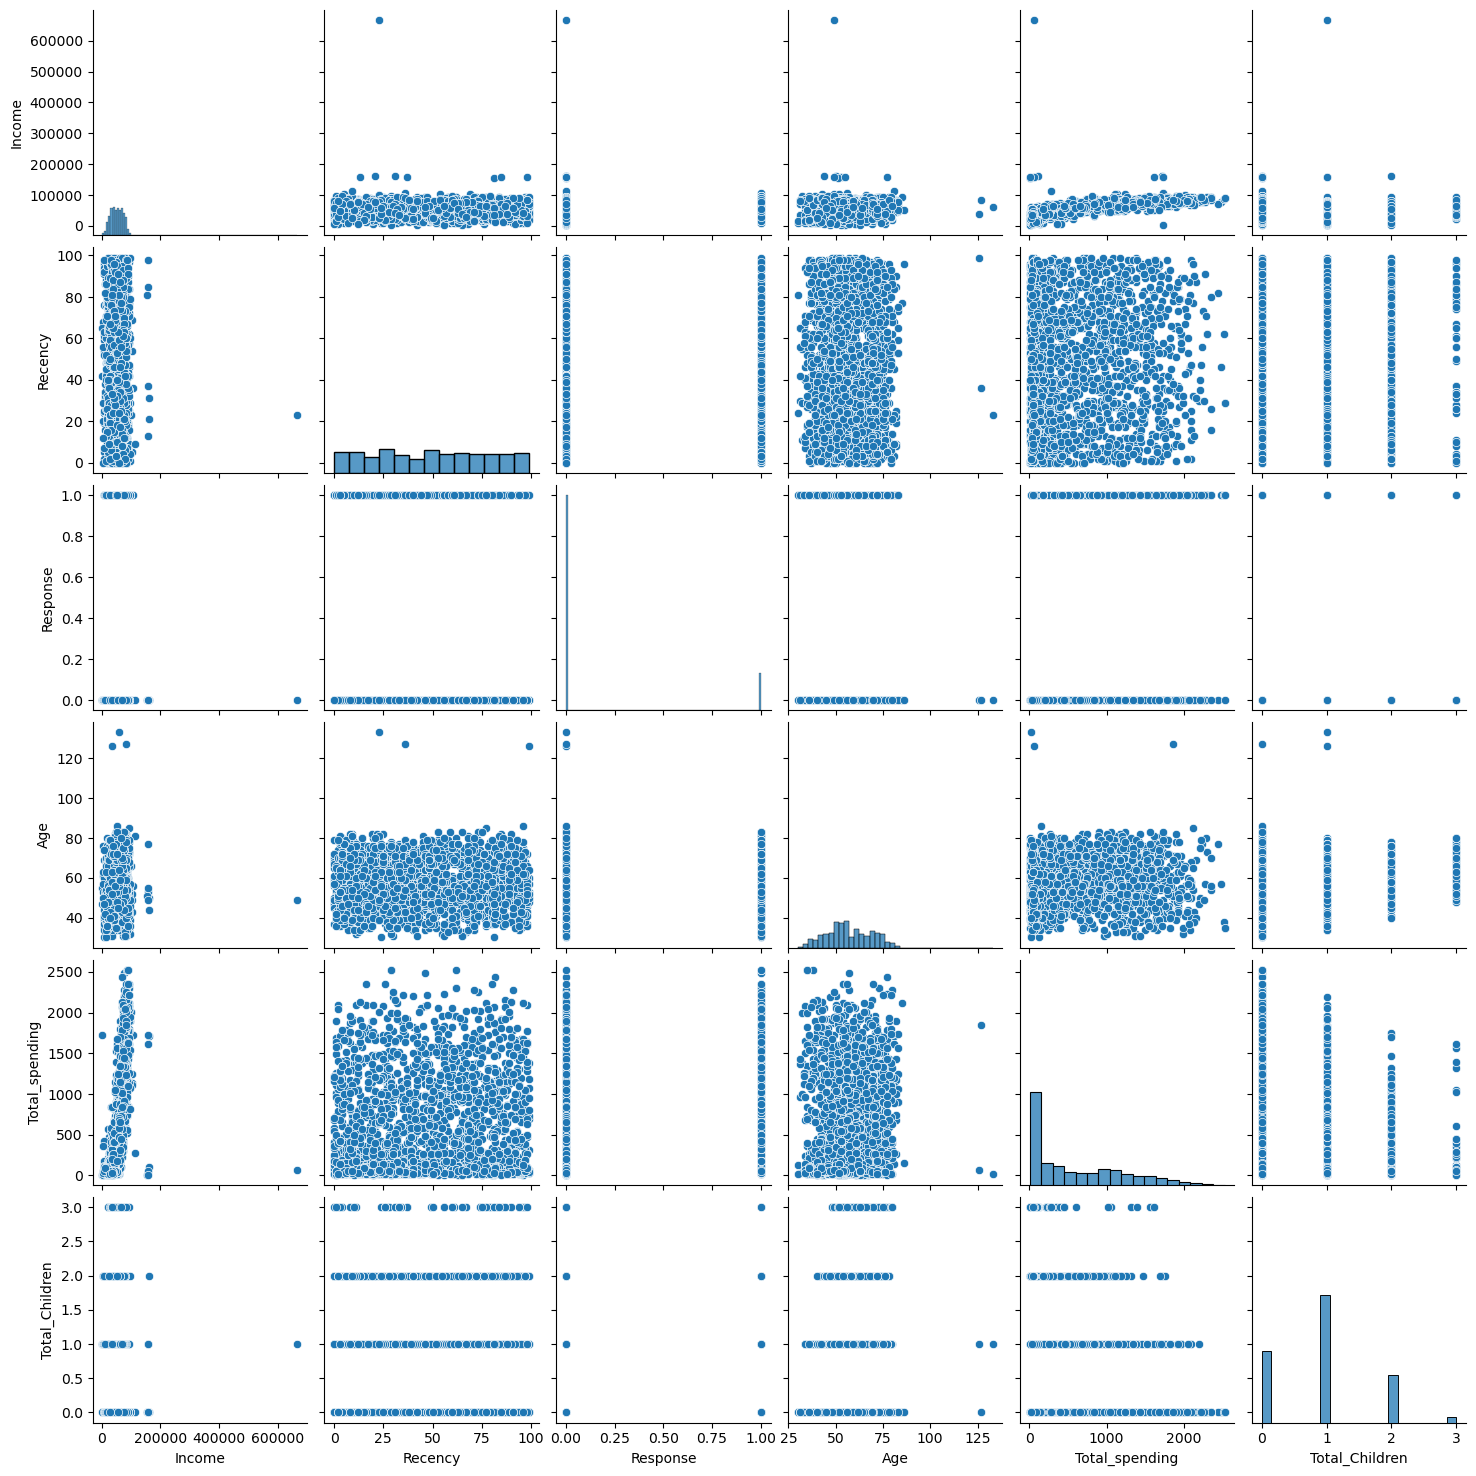

In [41]:
cols = ["Income", "Recency", "Response","Age","Total_spending","Total_Children"]

# Relative plots of some features --- pair plots to look for outliers
sns.pairplot(data_cleaned[cols])

In [42]:
# 3 Removed outliers from the dataset

print("data size with outliers: ", len(data_cleaned))

data_cleaned = data_cleaned[data_cleaned["Age"] < 90]
data_cleaned = data_cleaned[data_cleaned["Income"] < 600_000]

print("data size without outliers: ", len(data_cleaned))



data size with outliers:  2240
data size without outliers:  2236


## HeatMap -- Correlation

<Axes: >

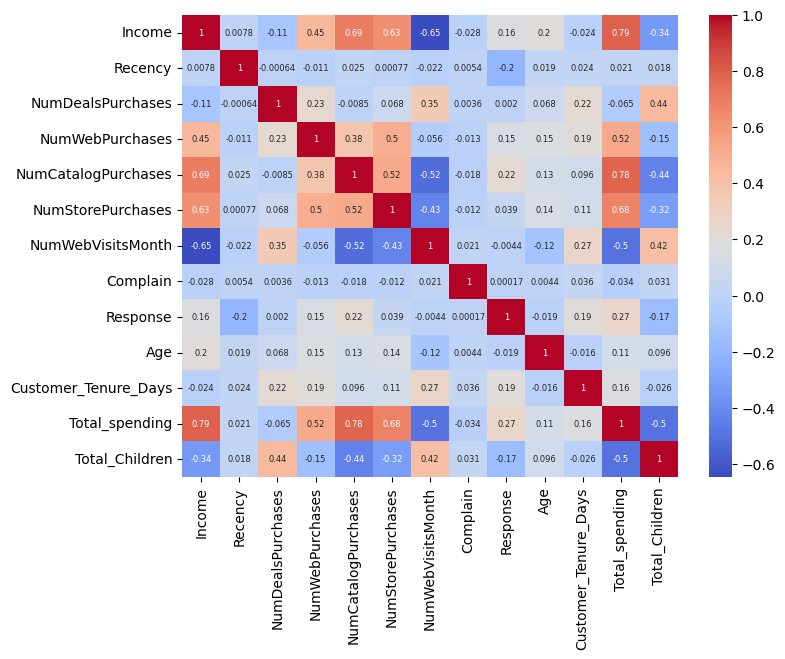

In [48]:
## Correlation matrix to see the correlation between features

corr = data_cleaned.corr(numeric_only = True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

## Encoding Features

In [49]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Living_with
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [50]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_col = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(data_cleaned[cat_col])

In [52]:
enc_data =pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_col), index=data_cleaned.index)

In [53]:
enc_data.head()

,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [55]:
data_encoded = pd.concat([data_cleaned.drop(columns=cat_col), enc_data], axis=1)

In [57]:
data_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [58]:
data_encoded.shape

(2236, 18)

## Scaling the data

In [60]:
X = data_encoded

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [69]:
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


## Visualization

In [65]:
X_scaled.shape

(2236, 18)

In [70]:
# Here we have 18 fetures on dataset now, so
# we have to do dimentionality reduction to visualize the data in 2D or 3D space.
# We can use PCA (Principal Component Analysis) for this purpose.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


<Axes: >

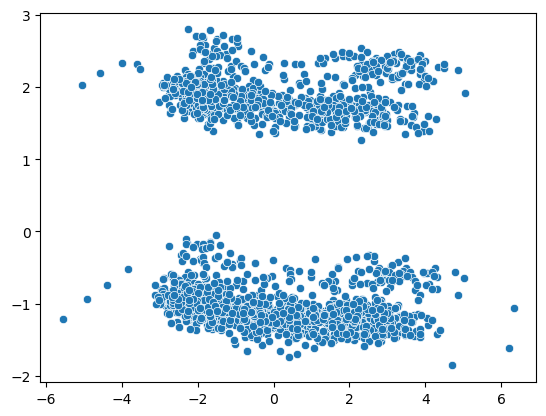

In [73]:
# Plotting the PCA results to visualize the data in 2D space

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1])

In [ ]:
## Here from 18 to 2 dinemtion .... we have lost so many information

In [ ]:
pca.explained_variance_ratio_

# Here ratio total is around 33 means PCA captured 33% of the variance
# so to reduce the information loss we chage 18 to 3d

array([0.23163158, 0.11385454])

In [79]:
## PCA with components = 3

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [80]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D PCA Scatter Plot')

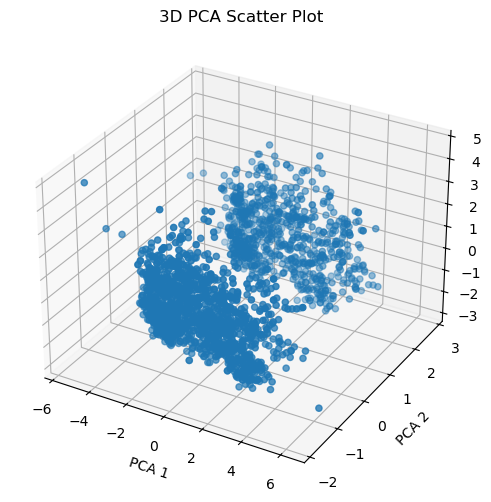

In [82]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('3D PCA Scatter Plot')

## Analyse The 'K' Value

#### 1. Elbow Method


In [83]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [86]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [88]:
print("best k:", optimal_k)

best k: 4


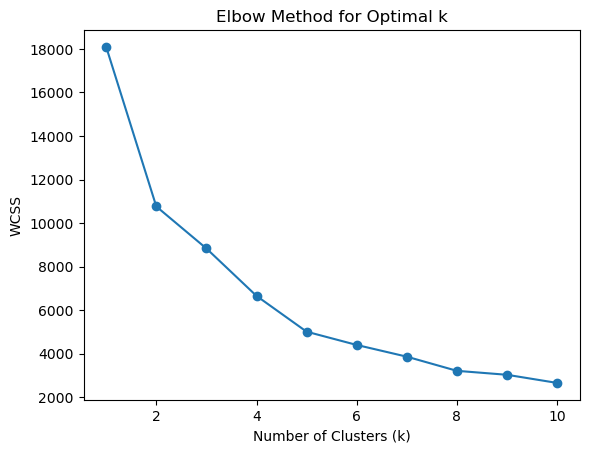

In [89]:
## Plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

#### 2. Silhouette Score

In [93]:
from sklearn.metrics import silhouette_score

score = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    score.append(silhouette_avg)




In [94]:
score

[0.3715793907976446,
 0.3076881927474974,
 0.3580996159596818,
 0.40001521476618634,
 0.39929183898565085,
 0.4026208740557631,
 0.4050858828690464,
 0.40118897046525365,
 0.40291173364815014]

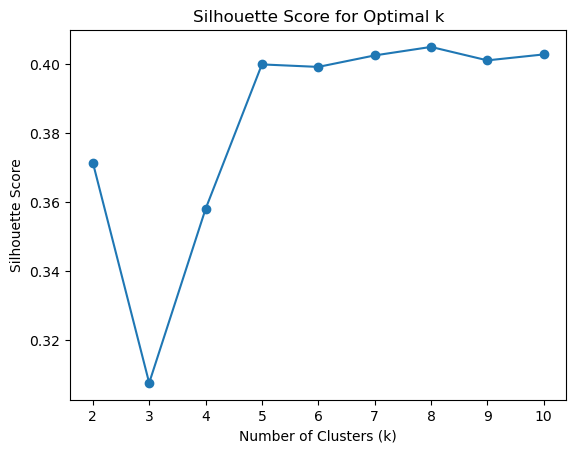

In [92]:
## Plotting the elbow method to visualize the optimal number of clusters

plt.plot(range(2, 11), score, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

Text(0, 0.5, 'Silhouette Score')

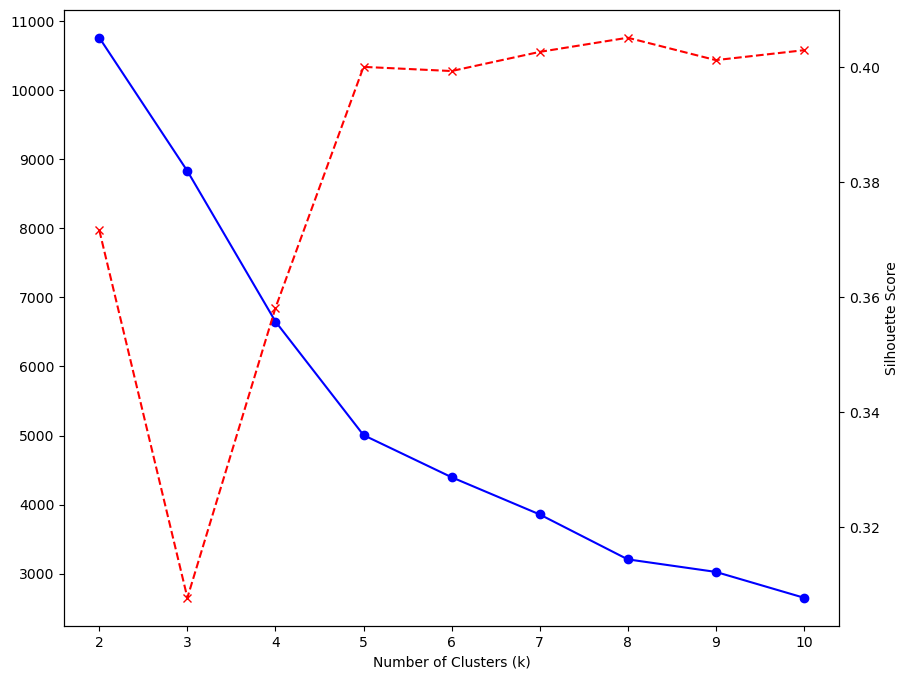

In [98]:
### COmbine plot of WCSS and Silhouette Score to find the optimal k

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(10, 8))

ax1.plot(k_range, wcss[1:], marker='o', color='b', label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_label('WCSS')

ax2 = ax1.twinx()
ax2.plot(k_range, score[: len(k_range)], marker='x', color='red', linestyle='--')
ax2.set_ylabel('Silhouette Score') 

In [ ]:
## Here our intersecton n plot is near '4', so our k = 4 is the best choice for clustering the data.

## Clustering

In [100]:
## Kmeans with optimal k = 4

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

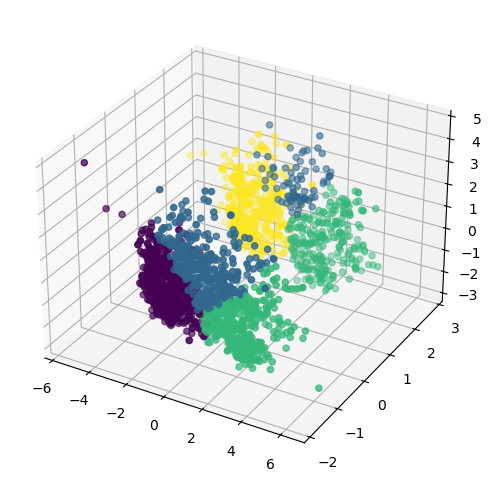

In [107]:
### Visualizing the clusters in 3D space

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels, marker='o')


In [109]:
### Same thing with Agglomerative clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

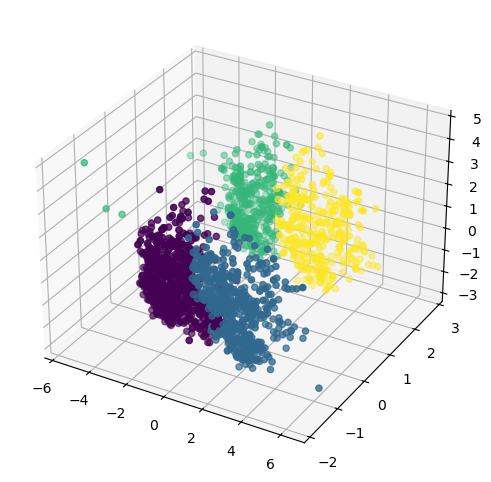

In [110]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg, marker='o')

In [112]:
## So here agglomerative clustering and kmeans clustering has better results
## It keeps the all similar datapoints together in a cluster
